In [5]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [6]:
print("CUDA available", torch.cuda.is_available())
print("GPU name", torch.cuda.get_device_name(0))

CUDA available True
GPU name Tesla T4


In [7]:
!pip install -q datasets

In [8]:
from datasets import load_dataset
dataset = load_dataset("ai4bharat/IndicSentiment-Translated")
print(dataset)

DatasetDict({
    validation: Dataset({
        features: ['GENERIC CATEGORIES', 'CATEGORY', 'SUB-CATEGORY', 'PRODUCT', 'BRAND', 'ASPECTS', 'ASPECT COMBO', 'ENGLISH REVIEW', 'LABEL', 'INDIC REVIEW', 'ITV2 HI REVIEW', 'ITV2 TE REVIEW', 'ITV2 KN REVIEW', 'ITV2 GU REVIEW', 'ITV2 OR REVIEW', 'ITV2 ML REVIEW', 'ITV2 BD REVIEW', 'ITV2 UR REVIEW', 'ITV2 AS REVIEW', 'ITV2 BN REVIEW', 'ITV2 MR REVIEW', 'ITV2 PA REVIEW', 'ITV2 TA REVIEW'],
        num_rows: 156
    })
    test: Dataset({
        features: ['GENERIC CATEGORIES', 'CATEGORY', 'SUB-CATEGORY', 'PRODUCT', 'BRAND', 'ASPECTS', 'ASPECT COMBO', 'ENGLISH REVIEW', 'LABEL', 'INDIC REVIEW', 'ITV2 HI REVIEW', 'ITV2 TE REVIEW', 'ITV2 KN REVIEW', 'ITV2 GU REVIEW', 'ITV2 OR REVIEW', 'ITV2 ML REVIEW', 'ITV2 BD REVIEW', 'ITV2 UR REVIEW', 'ITV2 AS REVIEW', 'ITV2 BN REVIEW', 'ITV2 MR REVIEW', 'ITV2 PA REVIEW', 'ITV2 TA REVIEW'],
        num_rows: 1000
    })
})


In [9]:
import datasets
print(datasets.__version__)

4.0.0


In [10]:
import pandas as pd
df_value = pd.DataFrame(dataset['validation'])
print("Total rows: ", len(df_value))
df_value.head()

Total rows:  156


,GENERIC CATEGORIES,CATEGORY,SUB-CATEGORY,PRODUCT,BRAND,ASPECTS,ASPECT COMBO,ENGLISH REVIEW,LABEL,INDIC REVIEW,...,ITV2 GU REVIEW,ITV2 OR REVIEW,ITV2 ML REVIEW,ITV2 BD REVIEW,ITV2 UR REVIEW,ITV2 AS REVIEW,ITV2 BN REVIEW,ITV2 MR REVIEW,ITV2 PA REVIEW,ITV2 TA REVIEW
0,Home,Appliances,Home theater,Soundbars,Boat,"Bluetooth/wireless, HDMI, audio output mode, i...",HDMI,This boat's soundbar is still wire-connectivit...,Negative,बोट के साउंडबार में अभी भी सभी स्पीकर्स के लिए...,...,The boat's soundbar is still wired-connectivit...,The boat's soundbar is still wired to all spea...,The boat's soundbar is still wired connectivit...,The boat's soundbar still has wire-connectivit...,The boot's soundbar is still wired to all spea...,The boat's soundbar still requires all speaker...,The boat's soundbar is still wired to all spea...,This Boat soundbar still has wired-connectivit...,This bot soundbar is still wired to all speake...,The boat's soundbar is still wired to all spea...
1,Hobbies,Music,Audio Output,headphones,Zeb Paradise,"on-ear, in-ear, wired, bluetooth, earbuds, noi...",Over-ear with mic,Foldable type of microphone with mic and micro...,Positive,माइक और माइक्रो एसडी कार्ड स्लॉट के साथ फोल्डे...,...,Foldable microphone with mic and micro SD card...,Foldable type microphone with mic and micro SD...,A foldable type of microphone with a mic and a...,Foldable microphone with mic and micro SD card...,Foldable type microphone with mic and microSD ...,Foldable type of microphone with mic and micro...,Foldable type of microphone with mic and micro...,Clockable microphone with mic and micro SD car...,There is a foldable type microphone with mic a...,Foldable type microphone with mic and micro SD...
2,Entertainment,Apps,Social Media,Social networking,Instagram,"find friends, share photos and moments, free m...",daily status,The recently included feature of stories by de...,Positive,हाल ही में डाला गया फीचर जो डिफ़ॉल्ट रूप से 24...,...,"The recently added feature of Stories, which i...",Very recently the feature of stories included ...,I'm so glad that the recently added feature of...,Recently added feature that shows 24 hours lon...,The recent feature of Stories being visible fo...,It makes me so happy to have the highlights of...,The feature of stories being visible by defaul...,I was very pleased with the recently added fea...,Recently added stories basically show up for 2...,I'm very pleased with the recently added Stori...
3,Transportation,Air,Flights,International,Emirates,"luggage allowance, affordable rates, luxury, f...",Rates Luggage allowance,"Rates are competitive, almost always the best ...",Positive,"""रेट्स प्रतिस्पर्धी हैं, लगभग मार्किट में सबसे...",...,"""Rates are competitive, almost always the best...","""The prices are competitive, almost always the...","""The rates are competitive and almost always t...","""The rates are competitive, almost the best in...","""Prices are competitive, almost always the bes...","""Rents are competitive, almost always the best...","""Bids are competitive, almost always the best ...","""Prices are competitive, often the best in the...","""Rates are competitive, almost always the best...","""Competitive pricing is the best available in ..."
4,Home,Appliances,Fan,Exhaust fan,Bajaj Maxima,"remove moisture/unpleasant odour, air delivery...",Front Shutter,Looks very big and efficient. But since there ...,Negative,बहुत बड़ा और बेहतरीन दिखता है। लेकिन चूंकि कोई...,...,Looks very big and functional. But since there...,Looks very large and efficient. But since ther...,Seems very large and efficient. But since ther...,Looks very big and classy. But since there is ...,Very large and effective; but since there is n...,Looks very large and functional. But since the...,"It looks very large and efficient, but since t...",Looks very large and functional. But due to th...,Looks very large and efficient. But since ther...,"Large in appearance and capable, but with no f..."


LABEL
Negative    81
Positive    75
Name: count, dtype: int64


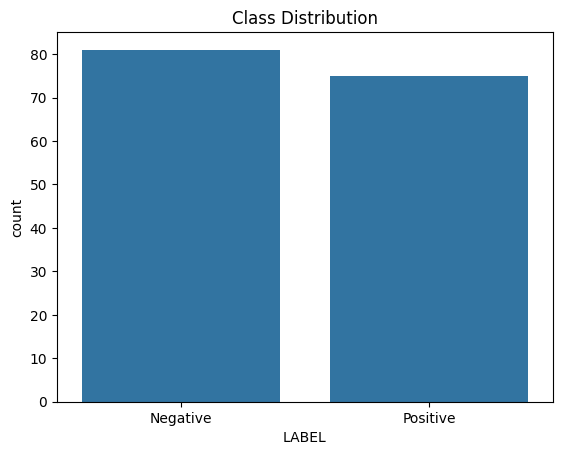

In [11]:
print(df_value['LABEL'].value_counts())
sns.countplot(data=df_value, x='LABEL')
plt.title('Class Distribution')
plt.show()

In [12]:
df_value['INDIC REVIEW'].str.len().describe()

,INDIC REVIEW
count,156.000000
mean,135.506410
std,70.607273
min,17.000000
25%,80.750000
50%,130.000000
75%,170.250000
max,403.000000


(array([ 1.,  8.,  8., 11., 13.,  7., 10.,  5., 19., 17.,  7., 13.,  6.,
         4.,  5.,  5.,  2.,  3.,  3.,  3.,  1.,  0.,  2.,  0.,  0.,  2.,
         0.,  0.,  0.,  1.]),
 array([ 17.        ,  29.86666667,  42.73333333,  55.6       ,
         68.46666667,  81.33333333,  94.2       , 107.06666667,
        119.93333333, 132.8       , 145.66666667, 158.53333333,
        171.4       , 184.26666667, 197.13333333, 210.        ,
        222.86666667, 235.73333333, 248.6       , 261.46666667,
        274.33333333, 287.2       , 300.06666667, 312.93333333,
        325.8       , 338.66666667, 351.53333333, 364.4       ,
        377.26666667, 390.13333333, 403.        ]),
 <BarContainer object of 30 artists>)

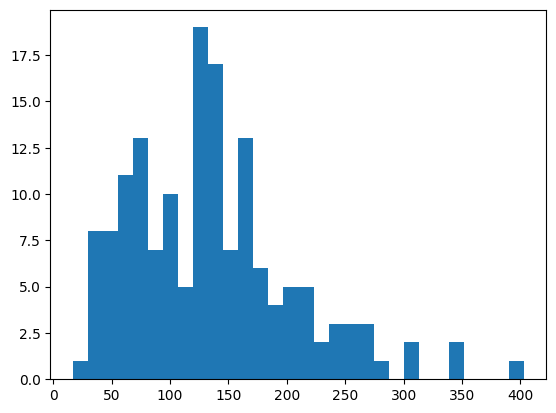

In [13]:
plt.hist(df_value['INDIC REVIEW'].str.len(), bins=30)

In [14]:
df_value['INDIC REVIEW'].str.split().str.len()

,INDIC REVIEW
0,28
1,10
2,25
3,10
4,31
...,...
151,28
152,39
153,81
154,15


In [15]:
df_value[df_value['LABEL'] == 'Positive']

,GENERIC CATEGORIES,CATEGORY,SUB-CATEGORY,PRODUCT,BRAND,ASPECTS,ASPECT COMBO,ENGLISH REVIEW,LABEL,INDIC REVIEW,...,ITV2 GU REVIEW,ITV2 OR REVIEW,ITV2 ML REVIEW,ITV2 BD REVIEW,ITV2 UR REVIEW,ITV2 AS REVIEW,ITV2 BN REVIEW,ITV2 MR REVIEW,ITV2 PA REVIEW,ITV2 TA REVIEW
1,Hobbies,Music,Audio Output,headphones,Zeb Paradise,"on-ear, in-ear, wired, bluetooth, earbuds, noi...",Over-ear with mic,Foldable type of microphone with mic and micro...,Positive,माइक और माइक्रो एसडी कार्ड स्लॉट के साथ फोल्डे...,...,Foldable microphone with mic and micro SD card...,Foldable type microphone with mic and micro SD...,A foldable type of microphone with a mic and a...,Foldable microphone with mic and micro SD card...,Foldable type microphone with mic and microSD ...,Foldable type of microphone with mic and micro...,Foldable type of microphone with mic and micro...,Clockable microphone with mic and micro SD car...,There is a foldable type microphone with mic a...,Foldable type microphone with mic and micro SD...
2,Entertainment,Apps,Social Media,Social networking,Instagram,"find friends, share photos and moments, free m...",daily status,The recently included feature of stories by de...,Positive,हाल ही में डाला गया फीचर जो डिफ़ॉल्ट रूप से 24...,...,"The recently added feature of Stories, which i...",Very recently the feature of stories included ...,I'm so glad that the recently added feature of...,Recently added feature that shows 24 hours lon...,The recent feature of Stories being visible fo...,It makes me so happy to have the highlights of...,The feature of stories being visible by defaul...,I was very pleased with the recently added fea...,Recently added stories basically show up for 2...,I'm very pleased with the recently added Stori...
3,Transportation,Air,Flights,International,Emirates,"luggage allowance, affordable rates, luxury, f...",Rates Luggage allowance,"Rates are competitive, almost always the best ...",Positive,"""रेट्स प्रतिस्पर्धी हैं, लगभग मार्किट में सबसे...",...,"""Rates are competitive, almost always the best...","""The prices are competitive, almost always the...","""The rates are competitive and almost always t...","""The rates are competitive, almost the best in...","""Prices are competitive, almost always the bes...","""Rents are competitive, almost always the best...","""Bids are competitive, almost always the best ...","""Prices are competitive, often the best in the...","""Rates are competitive, almost always the best...","""Competitive pricing is the best available in ..."
5,Education,Books,Children's book,Picture books,Sam Sam and Marzipan: The Cubby House,"cute cover design, colourfull, activity orient...",Attractive pictures,I gave this book a 5 star review because it is...,Positive,मैंने इस बुक को 5 स्टार रिव्यु दिया है क्योंकि...,...,I gave this book a 5 star review because it is...,I gave this book a 5 star review because it's ...,I gave this book a 5 star review because it is...,I've given this book a 5 star review because i...,I've given this book a 5 star review because i...,I gave this book a 5 star review because it is...,I gave this book a 5 star review because it ha...,I gave this book a 5 star review because it ha...,I gave this book a 5 star review because it is...,I have given this book a 5 star review because...
15,Entertainment,Movies,Genres,Tragedy,Haider,"serious, storyline, performances, emotional, m...",Storyline and Performances,Haider is an unforgettable film that never fum...,Positive,हैदर एक ऐसी कभी न भूले जाने वाली फिल्म है जो क...,...,Haider is an unforgettable film that never fal...,Haider is an unforgettable film that never fal...,Haider is an unforgettable film that never fli...,"Haider is a film that never messes up, never s...",Haider is an unforgettable film that never pan...,Haider is an unforgettable movie that never di...,Haider is an unforgettable film that will neve...,Haider is an unforgettable film that doesn't g...,Haider is an unforgettable film that never fal...,"Haider is an unforg

In [16]:
df_value[df_value['LABEL'] == 'Positive']['INDIC REVIEW']

,INDIC REVIEW
1,माइक और माइक्रो एसडी कार्ड स्लॉट के साथ फोल्डे...
2,हाल ही में डाला गया फीचर जो डिफ़ॉल्ट रूप से 24...
3,"""रेट्स प्रतिस्पर्धी हैं, लगभग मार्किट में सबसे..."
5,मैंने इस बुक को 5 स्टार रिव्यु दिया है क्योंकि...
15,हैदर एक ऐसी कभी न भूले जाने वाली फिल्म है जो क...
...,...
148,इसमें लंबे समय तक चलने वाली और अद्भुत खुशबू है...
149,यह एक अद्भुत फीचर है जो प्रोडक्ट की दक्षता को ...
150,यह नए लोगों के लिए सबसे अच्छा है क्योंकि यह बि...
151,आईकॉल (IKall) ने अब डॉल्बी आउटपुट के साथ एक नय...


In [17]:
df_value[df_value['LABEL'] == 'Positive']['INDIC REVIEW'].head(3)

,INDIC REVIEW
1,माइक और माइक्रो एसडी कार्ड स्लॉट के साथ फोल्डे...
2,हाल ही में डाला गया फीचर जो डिफ़ॉल्ट रूप से 24...
3,"""रेट्स प्रतिस्पर्धी हैं, लगभग मार्किट में सबसे..."


In [18]:
for review in df_value[df_value['LABEL'] == 'Positive']['INDIC REVIEW'].head(3).tolist():
       print(review)
       print("---")

माइक और माइक्रो एसडी कार्ड स्लॉट के साथ फोल्डेबल माइक्रोफ़ोन।
---
हाल ही में डाला गया फीचर जो डिफ़ॉल्ट रूप से 24 घंटे तक स्टोरीज़ दिखाता है, मुझे काफी अच्छा लगा। सोशल कनेक्शन बड़े आराम से!
---
"रेट्स प्रतिस्पर्धी हैं, लगभग मार्किट में सबसे बेस्ट हैं। "
---


In [19]:
df_test = pd.DataFrame(dataset['test'])

In [20]:
label_map = {"Negative": 0, "Positive": 1}

In [21]:
df_value['label_id'] = df_value['LABEL'].map(label_map)

In [22]:
df_test['label_id'] = df_test['LABEL'].map(label_map)

In [23]:
df_value[['LABEL', 'label_id']].head(10)

,LABEL,label_id
0,Negative,0
1,Positive,1
2,Positive,1
3,Positive,1
4,Negative,0
5,Positive,1
6,Negative,0
7,Negative,0
8,Negative,0
9,Negative,0


In [24]:
import transformers
print(transformers.__version__)
import huggingface_hub
print(huggingface_hub.__version__)

5.0.0
1.16.1


In [25]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google/muril-base-cased")
print("Tokenizer loaded successfully")
print("Vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/3.16M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded successfully
Vocab size: 197258


In [26]:
sample = df_value['INDIC REVIEW'].iloc[0]
print("Original text:")
print(sample)

Original text:
बोट के साउंडबार में अभी भी सभी स्पीकर्स के लिए वायर-कनेक्टिविटी है। एचडीएमआई पोर्ट सभी डिवाइसेज़ से मेल नहीं खाता है, इसलिए यह कभी-कभी डिस्कनेक्ट हो जाता है।


In [27]:
encoded = tokenizer(sample)
print("\nEncoded output (the dictionary):")
print(encoded)


Encoded output (the dictionary):
{'input_ids': [104, 39744, 1110, 123244, 22997, 1114, 4588, 1179, 2056, 99162, 1615, 1110, 1198, 150291, 120, 163796, 1115, 492, 79988, 17205, 16062, 35051, 2056, 51065, 1216, 26007, 1124, 10201, 1254, 24294, 1115, 119, 4066, 1233, 2893, 120, 2893, 40399, 1530, 47757, 120368, 1367, 1115, 492, 105], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [28]:
tokens = tokenizer.convert_ids_to_tokens(encoded['input_ids'])
print("\nActual tokens:")
print(tokens)


Actual tokens:
['[CLS]', 'बोट', 'के', 'साउंड', '##बार', 'में', 'अभी', 'भी', 'सभी', 'स्पीकर', '##्स', 'के', 'लिए', 'वायर', '-', 'कनेक्टिविटी', 'है', '।', 'एचडी', '##एम', '##आई', 'पोर्ट', 'सभी', 'डिवाइस', '##े', '##ज़', 'से', 'मेल', 'नहीं', 'खाता', 'है', ',', 'इसलिए', 'यह', 'कभी', '-', 'कभी', 'डिस्क', '##ने', '##क्ट', 'हो', 'जाता', 'है', '।', '[SEP]']


In [29]:
val_texts = df_value['INDIC REVIEW'].tolist()

In [30]:
val_encodings = tokenizer(
       val_texts,
       padding='max_length',
       truncation=True,
       max_length=128,
       return_tensors='pt'
   )

In [31]:
print("input_ids shape:", val_encodings['input_ids'].shape)
print("attention_mask shape:", val_encodings['attention_mask'].shape)

input_ids shape: torch.Size([156, 128])
attention_mask shape: torch.Size([156, 128])


In [32]:
import torch
from torch.utils.data import Dataset

class HindiSentimentDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

In [34]:
train_labels = df_value['label_id'].astype(int).tolist()

# Ensure df_test has no NaN values in 'LABEL' before mapping to 'label_id'
# and then converting to int. This makes the label creation robust.
df_test_temp = df_test.dropna(subset=['LABEL']).reset_index(drop=True)
df_test_temp['label_id'] = df_test_temp['LABEL'].map(label_map)

test_labels = df_test_temp['label_id'].astype(int).tolist()

In [35]:
train_dataset = HindiSentimentDataset(val_encodings, train_labels)

test_texts = df_test['INDIC REVIEW'].tolist()
test_encodings = tokenizer(
    test_texts,
    padding='max_length',
    truncation=True,
    max_length=128,
    return_tensors='pt'
)
test_dataset = HindiSentimentDataset(test_encodings, test_labels)

In [36]:
print("Train dataset size:", len(train_dataset))
print("\nFirst example:")
print(train_dataset[0])

Train dataset size: 156

First example:
{'input_ids': tensor([   104,  39744,   1110, 123244,  22997,   1114,   4588,   1179,   2056,
         99162,   1615,   1110,   1198, 150291,    120, 163796,   1115,    492,
         79988,  17205,  16062,  35051,   2056,  51065,   1216,  26007,   1124,
         10201,   1254,  24294,   1115,    119,   4066,   1233,   2893,    120,
          2893,  40399,   1530,  47757, 120368,   1367,   1115,    492,    105,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,   

In [37]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "google/muril-base-cased",
    num_labels=2
)

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: google/muril-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expe

In [38]:
print(f"Model loaded: {model.__class__.__name__}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")

Model loaded: BertForSequenceClassification
Number of parameters: 237,557,762


In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=20,
    weight_decay=0.01,
    logging_steps=10,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    fp16=True,
    report_to='none'
)

In [40]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {
        'accuracy': accuracy_score(labels, predictions),
        'f1': f1_score(labels, predictions, average='weighted')
    }

In [41]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.693386,0.693083,0.507014,0.341156
2,0.692849,0.692551,0.718437,0.718450
3,0.689211,0.688490,0.717435,0.717271


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=30, training_loss=0.6918152014414469, metrics={'train_runtime': 183.9559, 'train_samples_per_second': 2.544, 'train_steps_per_second': 0.163, 'total_flos': 30783993477120.0, 'train_loss': 0.6918152014414469, 'epoch': 3.0})

In [42]:
print("Validation set unique LABEL values:", df_value['LABEL'].unique())
print("Validation set NaN labels:", df_value['label_id'].isna().sum())
print()
print("Test set unique LABEL values:", df_test['LABEL'].unique())
print("Test set NaN labels:", df_test['label_id'].isna().sum())

Validation set unique LABEL values: ['Negative' 'Positive']
Validation set NaN labels: 0

Test set unique LABEL values: ['Negative' 'Positive' None]
Test set NaN labels: 2


In [43]:
print("Label dtype:", train_dataset[0]['labels'].dtype)

Label dtype: torch.int64


In [45]:
import pandas as pd
from datasets import load_dataset # Ensure load_dataset is available
dataset = load_dataset("ai4bharat/IndicSentiment-Translated") # Re-load dataset if not already loaded
df_test = pd.DataFrame(dataset['test']) # Re-initialize df_test
df_test = df_test.dropna(subset=['LABEL']).reset_index(drop=True)
print(f"Test set after dropping NaN: {len(df_test)} rows")

Test set after dropping NaN: 998 rows


In [46]:
import numpy as np
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

In [47]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(cm)
print()
print("Classification report:")
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

Confusion matrix:
[[408  84]
 [220 286]]

Classification report:
              precision    recall  f1-score   support

    Negative       0.65      0.83      0.73       492
    Positive       0.77      0.57      0.65       506

    accuracy                           0.70       998
   macro avg       0.71      0.70      0.69       998
weighted avg       0.71      0.70      0.69       998



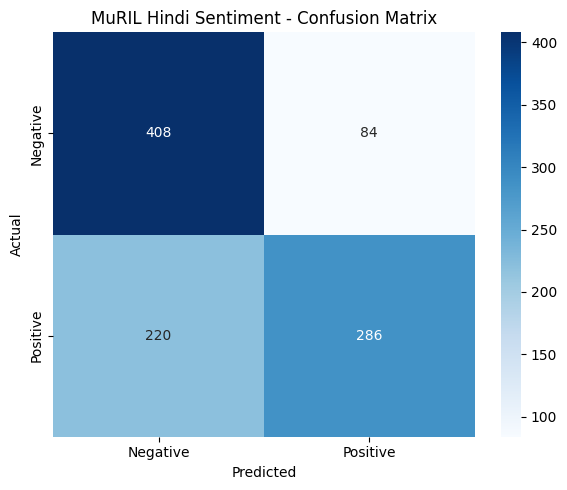

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('MuRIL Hindi Sentiment - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_muril_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

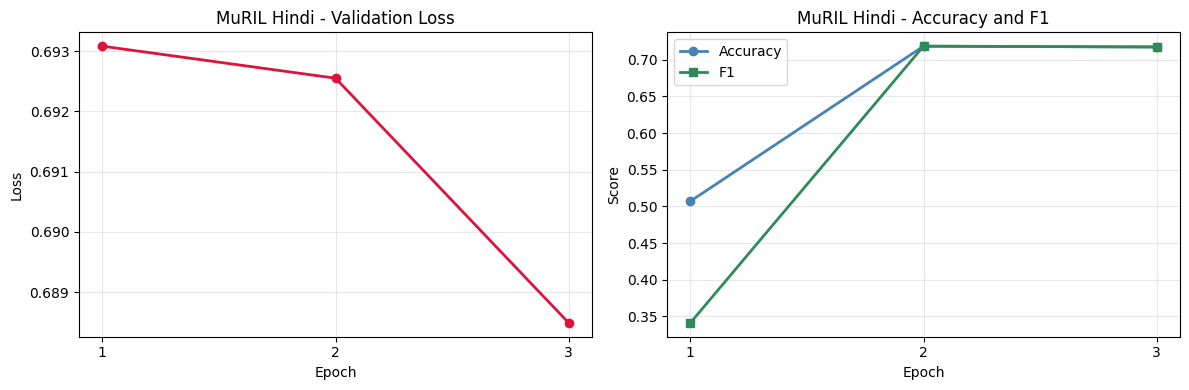

In [49]:
log_history = trainer.state.log_history

eval_losses = [log['eval_loss'] for log in log_history if 'eval_loss' in log]
eval_accs = [log['eval_accuracy'] for log in log_history if 'eval_accuracy' in log]
eval_f1s = [log['eval_f1'] for log in log_history if 'eval_f1' in log]

epochs = list(range(1, len(eval_losses) + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
axes[0].plot(epochs, eval_losses, marker='o', linewidth=2, color='crimson')
axes[0].set_title('MuRIL Hindi - Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs)
axes[0].grid(True, alpha=0.3)

# Accuracy and F1 curve (both on same plot)
axes[1].plot(epochs, eval_accs, marker='o', linewidth=2, label='Accuracy', color='steelblue')
axes[1].plot(epochs, eval_f1s, marker='s', linewidth=2, label='F1', color='seagreen')
axes[1].set_title('MuRIL Hindi - Accuracy and F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_xticks(epochs)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_muril_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

In [50]:
results = {}
results['MuRIL'] = {
    'accuracy': 0.7174,
    'f1': 0.7173,
    'confusion_matrix': cm.tolist()
}
print(results)

{'MuRIL': {'accuracy': 0.7174, 'f1': 0.7173, 'confusion_matrix': [[408, 84], [220, 286]]}}


In [51]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-cased")
print("mBERT tokenizer loaded. Vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

mBERT tokenizer loaded. Vocab size: 119547


In [52]:
val_texts = df_value['INDIC REVIEW'].tolist()
val_encodings = tokenizer(val_texts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

test_texts = df_test['INDIC REVIEW'].tolist()
test_encodings = tokenizer(test_texts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

print("Tokenized for mBERT")
print("Train shape:", val_encodings['input_ids'].shape)
print("Test shape:", test_encodings['input_ids'].shape)

Tokenized for mBERT
Train shape: torch.Size([156, 128])
Test shape: torch.Size([998, 128])


In [53]:
train_dataset = HindiSentimentDataset(val_encodings, train_labels)
test_dataset = HindiSentimentDataset(test_encodings, test_labels)
print("Datasets rebuilt for mBERT")

Datasets rebuilt for mBERT


In [54]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-multilingual-cased",
    num_labels=2
)
print("mBERT loaded. Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


mBERT loaded. Parameters: 177,854,978


In [55]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [56]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.703975,0.692713,0.528056,0.464794
2,0.687950,0.670617,0.659319,0.657794
3,0.636768,0.580414,0.787575,0.787560


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=30, training_loss=0.676231050491333, metrics={'train_runtime': 87.1533, 'train_samples_per_second': 5.37, 'train_steps_per_second': 0.344, 'total_flos': 30783993477120.0, 'train_loss': 0.676231050491333, 'epoch': 3.0})

In [57]:
results['mBERT'] = {
    'accuracy': 0.7876,
    'f1': 0.7876
}
print(results)

{'MuRIL': {'accuracy': 0.7174, 'f1': 0.7173, 'confusion_matrix': [[408, 84], [220, 286]]}, 'mBERT': {'accuracy': 0.7876, 'f1': 0.7876}}


[[384 108]
 [104 402]]
              precision    recall  f1-score   support

    Negative       0.79      0.78      0.78       492
    Positive       0.79      0.79      0.79       506

    accuracy                           0.79       998
   macro avg       0.79      0.79      0.79       998
weighted avg       0.79      0.79      0.79       998



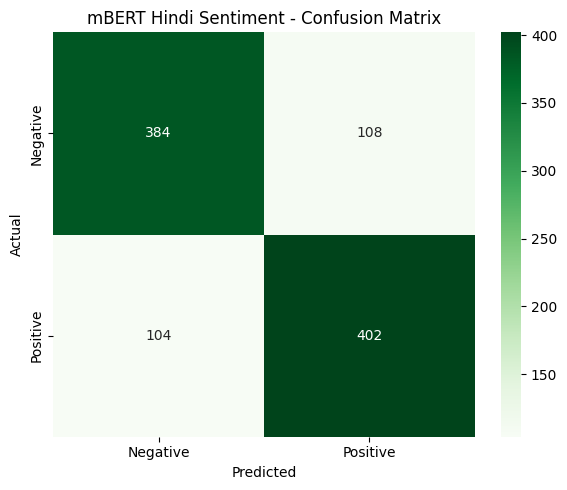

In [58]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

cm_mbert = confusion_matrix(y_true, y_pred)
print(cm_mbert)
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
sns.heatmap(cm_mbert, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('mBERT Hindi Sentiment - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_mbert_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

# Also save the matrix in results
results['mBERT']['confusion_matrix'] = cm_mbert.tolist()

In [59]:
from collections import Counter

# Step 1: Tokenize all training reviews (simple whitespace split)
train_tokens = [review.split() for review in df_value['INDIC REVIEW'].tolist()]

# Step 2: Count word frequencies across all training data
word_counts = Counter()
for tokens in train_tokens:
    word_counts.update(tokens)

print(f"Total unique words in training data: {len(word_counts)}")
print(f"Top 10 most common words: {word_counts.most_common(10)}")

Total unique words in training data: 1465
Top 10 most common words: [('के', 160), ('है।', 140), ('और', 126), ('में', 102), ('से', 83), ('है', 83), ('यह', 81), ('नहीं', 77), ('लिए', 65), ('की', 64)]


In [60]:
word_to_id = {'<PAD>': 0, '<UNK>': 1}
for word, count in word_counts.most_common():
    word_to_id[word] = len(word_to_id)

vocab_size = len(word_to_id)
print(f"Total vocab size: {vocab_size}")
print(f"ID of '<PAD>': {word_to_id['<PAD>']}")
print(f"ID of '<UNK>': {word_to_id['<UNK>']}")
print(f"ID of 'के' (most common word): {word_to_id['के']}")
print(f"ID of 'है': {word_to_id['है']}")

Total vocab size: 1467
ID of '<PAD>': 0
ID of '<UNK>': 1
ID of 'के' (most common word): 2
ID of 'है': 7


In [61]:
MAX_LEN = 50  # Fixed sequence length

def text_to_ids(text, word_to_id, max_len=MAX_LEN):
    tokens = text.split()
    ids = [word_to_id.get(word, word_to_id['<UNK>']) for word in tokens]
    # Pad or truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
    else:
        ids = ids + [word_to_id['<PAD>']] * (max_len - len(ids))
    return ids

In [62]:
import torch

train_ids = [text_to_ids(review, word_to_id) for review in df_value['INDIC REVIEW'].tolist()]
test_ids = [text_to_ids(review, word_to_id) for review in df_test['INDIC REVIEW'].tolist()]

train_ids_tensor = torch.tensor(train_ids, dtype=torch.long)
test_ids_tensor = torch.tensor(test_ids, dtype=torch.long)

# Labels we already have, just convert to tensors
train_labels_tensor = torch.tensor(train_labels, dtype=torch.long)
test_labels_tensor = torch.tensor(test_labels, dtype=torch.long)

print(f"Train IDs shape: {train_ids_tensor.shape}")
print(f"Test IDs shape: {test_ids_tensor.shape}")
print(f"\nFirst training example (first 30 IDs):")
print(train_ids_tensor[0][:30])
print(f"Label of first example: {train_labels_tensor[0]}")

Train IDs shape: torch.Size([156, 50])
Test IDs shape: torch.Size([998, 50])

First training example (first 30 IDs):
tensor([270,   2, 476,   5, 271,  17,  38, 477,   2,  10, 478,   3, 139, 479,
         38, 480,   6, 272,   9, 273,  15,  75,   8, 481, 482,  39,  49,   3,
          0,   0])
Label of first example: 0


In [63]:
import torch
import torch.nn as nn

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=64, num_classes=2, dropout=0.3):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):

        embedded = self.embedding(x)


        lstm_out, (h_n, c_n) = self.lstm(embedded)

        h_forward = h_n[0]
        h_backward = h_n[1]
        h_combined = torch.cat([h_forward, h_backward], dim=1)

        h_combined = self.dropout(h_combined)
        output = self.fc(h_combined)

        return output

In [64]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

lstm_model = BiLSTMClassifier(vocab_size=vocab_size).to(device)
print(lstm_model)
print(f"\nTotal parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

Using device: cuda
BiLSTMClassifier(
  (embedding): Embedding(1467, 128, padding_idx=0)
  (lstm): LSTM(128, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

Total parameters: 287,362


In [65]:
from torch.utils.data import DataLoader, TensorDataset

train_dataset_lstm = TensorDataset(train_ids_tensor, train_labels_tensor)
test_dataset_lstm = TensorDataset(test_ids_tensor, test_labels_tensor)

train_loader = DataLoader(train_dataset_lstm, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset_lstm, batch_size=32, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Test batches per epoch: {len(test_loader)}")

Train batches per epoch: 10
Test batches per epoch: 32


In [66]:
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [68]:
from sklearn.metrics import accuracy_score, f1_score

NUM_EPOCHS = 10
train_losses = []
test_losses = []
test_accuracies = []
test_f1s = []

for epoch in range(NUM_EPOCHS):
    lstm_model.train()
    epoch_train_loss = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        outputs = lstm_model(batch_x)

        loss = loss_fn(outputs, batch_y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    lstm_model.eval()
    epoch_test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            outputs = lstm_model(batch_x)
            loss = loss_fn(outputs, batch_y)
            epoch_test_loss += loss.item()

            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch_y.cpu().numpy())

    avg_test_loss = epoch_test_loss / len(test_loader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')

    test_losses.append(avg_test_loss)
    test_accuracies.append(accuracy)
    test_f1s.append(f1)

    print(f"Epoch {epoch+1:2d}/{NUM_EPOCHS} | Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Acc: {accuracy:.4f} | F1: {f1:.4f}")

Epoch  1/10 | Train Loss: 0.6906 | Test Loss: 0.6890 | Acc: 0.5301 | F1: 0.5140
Epoch  2/10 | Train Loss: 0.6429 | Test Loss: 0.6862 | Acc: 0.5371 | F1: 0.5075
Epoch  3/10 | Train Loss: 0.6002 | Test Loss: 0.6823 | Acc: 0.5411 | F1: 0.5184
Epoch  4/10 | Train Loss: 0.5518 | Test Loss: 0.6782 | Acc: 0.5511 | F1: 0.5298
Epoch  5/10 | Train Loss: 0.5013 | Test Loss: 0.6727 | Acc: 0.5681 | F1: 0.5494
Epoch  6/10 | Train Loss: 0.4288 | Test Loss: 0.6607 | Acc: 0.5922 | F1: 0.5809
Epoch  7/10 | Train Loss: 0.3489 | Test Loss: 0.6372 | Acc: 0.6293 | F1: 0.6238
Epoch  8/10 | Train Loss: 0.2272 | Test Loss: 0.6522 | Acc: 0.6743 | F1: 0.6619
Epoch  9/10 | Train Loss: 0.1737 | Test Loss: 0.6577 | Acc: 0.6834 | F1: 0.6769
Epoch 10/10 | Train Loss: 0.1032 | Test Loss: 0.8019 | Acc: 0.6273 | F1: 0.5928


In [69]:
results['BiLSTM'] = {
    'accuracy': 0.6834,
    'f1': 0.6769,
    'best_epoch': 9,
    'note': 'Peaked at epoch 9; overfit thereafter'
}
print(results)

{'MuRIL': {'accuracy': 0.7174, 'f1': 0.7173, 'confusion_matrix': [[408, 84], [220, 286]]}, 'mBERT': {'accuracy': 0.7876, 'f1': 0.7876, 'confusion_matrix': [[384, 108], [104, 402]]}, 'BiLSTM': {'accuracy': 0.6834, 'f1': 0.6769, 'best_epoch': 9, 'note': 'Peaked at epoch 9; overfit thereafter'}}


              precision    recall  f1-score   support

    Negative       0.58      0.92      0.71       492
    Positive       0.82      0.34      0.48       506

    accuracy                           0.63       998
   macro avg       0.70      0.63      0.59       998
weighted avg       0.70      0.63      0.59       998



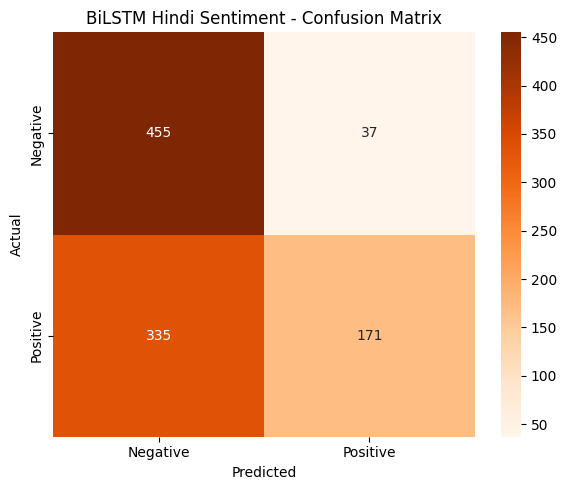

In [70]:
lstm_model.eval()
all_preds_lstm = []
all_labels_lstm = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        outputs = lstm_model(batch_x)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds_lstm.extend(preds)
        all_labels_lstm.extend(batch_y.numpy())

cm_lstm = confusion_matrix(all_labels_lstm, all_preds_lstm)
print(classification_report(all_labels_lstm, all_preds_lstm, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('BiLSTM Hindi Sentiment - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_bilstm_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

results['BiLSTM']['confusion_matrix'] = cm_lstm.tolist()

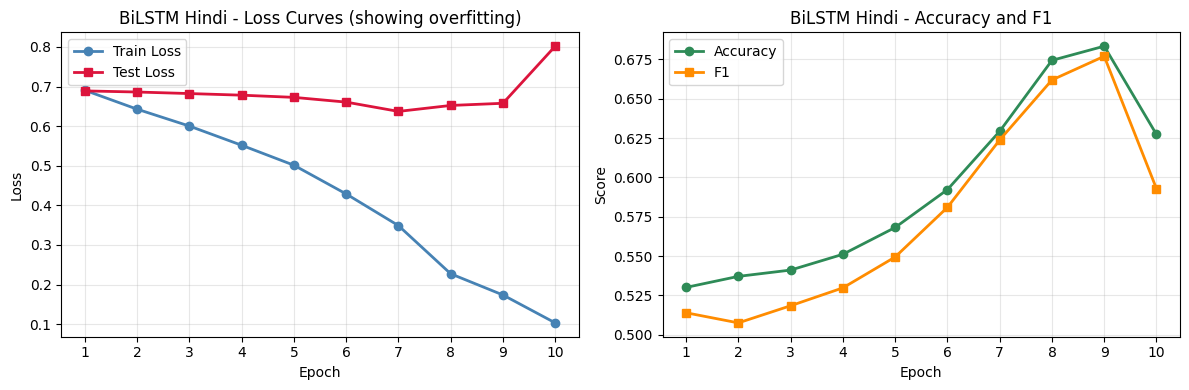

In [71]:
epochs_range = list(range(1, NUM_EPOCHS + 1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, marker='o', linewidth=2, label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, test_losses, marker='s', linewidth=2, label='Test Loss', color='crimson')
axes[0].set_title('BiLSTM Hindi - Loss Curves (showing overfitting)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_xticks(epochs_range)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, test_accuracies, marker='o', linewidth=2, label='Accuracy', color='seagreen')
axes[1].plot(epochs_range, test_f1s, marker='s', linewidth=2, label='F1', color='darkorange')
axes[1].set_title('BiLSTM Hindi - Accuracy and F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_xticks(epochs_range)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves_bilstm_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

In [72]:
from google.colab import userdata
hf_token = userdata.get('HF_TOKEN')
print(f"Token starts with: {hf_token[:10]}..." if hf_token else "No token found")

Token starts with: hf_AjHSrgz...


In [73]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get('HF_TOKEN'))
print("Logged in to HuggingFace")

Logged in to HuggingFace


In [80]:
tokenizer = AutoTokenizer.from_pretrained("ai4bharat/IndicBERTv2-MLM-only")
print("IndicBERT tokenizer loaded. Vocab size:", tokenizer.vocab_size)

config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.75M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

IndicBERT tokenizer loaded. Vocab size: 250000


In [82]:
val_texts = df_value['INDIC REVIEW'].tolist()
val_encodings = tokenizer(val_texts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

test_texts = df_test['INDIC REVIEW'].tolist()
test_encodings = tokenizer(test_texts, padding='max_length', truncation=True, max_length=128, return_tensors='pt')

print("Tokenized for IndicBERT")
print("Train shape:", val_encodings['input_ids'].shape)
print("Test shape:", test_encodings['input_ids'].shape)

Tokenized for IndicBERT
Train shape: torch.Size([156, 128])
Test shape: torch.Size([998, 128])


In [83]:
train_dataset = HindiSentimentDataset(val_encodings, train_labels)
test_dataset = HindiSentimentDataset(test_encodings, test_labels)
print("Datasets rebuilt for IndicBERT")

Datasets rebuilt for IndicBERT


In [84]:
model = AutoModelForSequenceClassification.from_pretrained(
    "ai4bharat/IndicBERTv2-MLM-only",
    num_labels=2
)
print("IndicBERT loaded. Parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ai4bharat/IndicBERTv2-MLM-only
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if y

IndicBERT loaded. Parameters: 278,042,882


In [85]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [86]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.695178,0.689507,0.600200,0.586189
2,0.674699,0.665040,0.618236,0.560021
3,0.613512,0.577354,0.778557,0.769330


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=30, training_loss=0.6611297607421875, metrics={'train_runtime': 542.2955, 'train_samples_per_second': 0.863, 'train_steps_per_second': 0.055, 'total_flos': 30783993477120.0, 'train_loss': 0.6611297607421875, 'epoch': 3.0})

In [87]:
results['IndicBERTv2'] = {
    'accuracy': 0.7786,
    'f1': 0.7693
}
print(results)

{'MuRIL': {'accuracy': 0.7174, 'f1': 0.7173, 'confusion_matrix': [[408, 84], [220, 286]]}, 'mBERT': {'accuracy': 0.7876, 'f1': 0.7876, 'confusion_matrix': [[384, 108], [104, 402]]}, 'BiLSTM': {'accuracy': 0.6834, 'f1': 0.6769, 'best_epoch': 9, 'note': 'Peaked at epoch 9; overfit thereafter', 'confusion_matrix': [[455, 37], [335, 171]]}, 'IndicBERTv2': {'accuracy': 0.7786, 'f1': 0.7693}}


              precision    recall  f1-score   support

    Negative       0.69      0.99      0.81       492
    Positive       0.98      0.58      0.73       506

    accuracy                           0.78       998
   macro avg       0.84      0.78      0.77       998
weighted avg       0.84      0.78      0.77       998



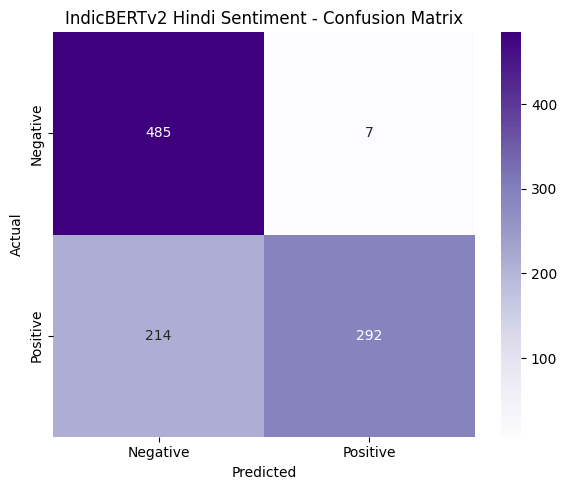

In [88]:
predictions_output = trainer.predict(test_dataset)
y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

cm_indicbert = confusion_matrix(y_true, y_pred)
print(classification_report(y_true, y_pred, target_names=['Negative', 'Positive']))

plt.figure(figsize=(6, 5))
sns.heatmap(cm_indicbert, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('IndicBERTv2 Hindi Sentiment - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix_indicbertv2_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

results['IndicBERTv2']['confusion_matrix'] = cm_indicbert.tolist()

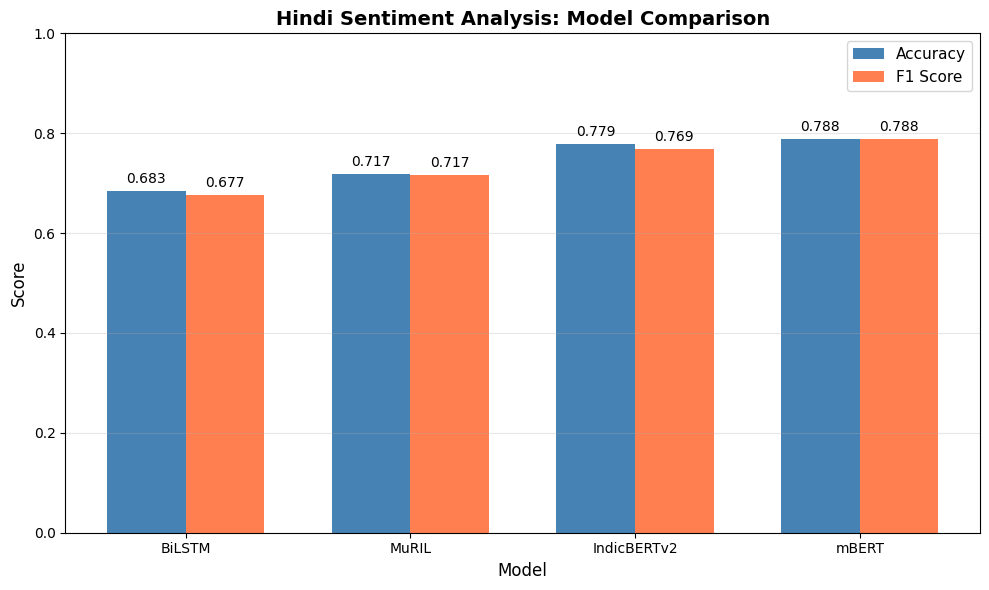

In [89]:
models_list = ['BiLSTM', 'MuRIL', 'IndicBERTv2', 'mBERT']
accuracies = [results[m]['accuracy'] for m in models_list]
f1_scores = [results[m]['f1'] for m in models_list]

x = np.arange(len(models_list))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores, width, label='F1 Score', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Hindi Sentiment Analysis: Model Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models_list)
ax.legend(fontsize=11)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01, f'{height:.3f}',
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('model_comparison_hindi.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [90]:
from google.colab import files

plot_files = [
    'confusion_matrix_muril_hindi.png',
    'training_curves_muril_hindi.png',
    'confusion_matrix_mbert_hindi.png',
    'confusion_matrix_bilstm_hindi.png',
    'training_curves_bilstm_hindi.png',
    'confusion_matrix_indicbertv2_hindi.png',
    'model_comparison_hindi.png'
]

for f in plot_files:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>